Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0  
Unless required by applicable law or agreed to in writing, software  
distributed under the License is distributed on an "AS IS" BASIS,  
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.  
See the License for the specific language governing permissions and  
limitations under the License.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Project-MONAI/tutorials/blob/main/modules/tcia_csv_processing.ipynb)

# Load National Lung Screening Trial (NLST) data from IDC with `CSVDataset` and process it

This tutorial shows how to load [National Lung Screening Trial (NLST)](https://doi.org/10.7937/TCIA.HMQ8-J677) data published by The Cancer Imaging Archive (TCIA) using the `idc-index` package developed by the [NCI Imaging Data Commons (IDC)](https://imaging.datacommons.cancer.gov/) to build a dataset compatible with MONAI's `CSVDataset` and fetch DICOM images for downstream processing.

IDC hosts all public TCIA DICOM datasets (including NLST) in cloud storage (AWS S3 / Google Cloud Storage) and provides a Python client for metadata queries and downloads — no authentication required.

**NLST Citation**
> National Lung Screening Trial Research Team. (2013). Data from the National Lung Screening Trial (NLST) [Data set]. The Cancer Imaging Archive. https://doi.org/10.7937/TCIA.HMQ8-J677



## Setup environment

In [1]:
!python -c "import monai" || pip install -q "monai-weekly[pandas]"
!pip install -q --upgrade idc-index
%matplotlib inline

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.1/74.1 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 71.5 MB/s eta 0:00:00


In [2]:
!pip install pydicom SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 12.6 MB/s eta 0:00:00


## Setup imports

In [3]:
import os
import tempfile
import shutil
import matplotlib.pyplot as plt
import pandas as pd
from typing import Any, Callable, Dict, Optional, Sequence, Union

from idc_index import IDCClient
from monai.data import CSVDataset
from monai.transforms import LoadImaged
from monai.config import print_config
from monai.utils import ensure_tuple

print_config()

MONAI version: 1.6.dev2614
Numpy version: 2.0.2
Pytorch version: 2.10.0+cpu
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d3272c9ecfbe622fc1c93a16cfdace71d6ac047c
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cpu
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://monai.readthedocs

## Setup data directory

You can specify a directory with the `MONAI_DATA_DIRECTORY` environment variable.  
This allows you to save results and reuse downloads.  
If not specified a temporary directory will be used.

In [4]:
directory = os.environ.get("MONAI_DATA_DIRECTORY")
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

/tmp/tmp2xixg5vu


## Define IDCDataset

It contains the following main logic:
1. Use `IDCClient` to query IDC metadata for a given collection and filters.
2. Save the query result as a CSV file and load it with `CSVDataset`.
3. Download the raw DICOM series on demand using `IDCClient.download_from_selection()`.
4. Execute transforms at runtime.

In [5]:
class IDCDataset(CSVDataset):
    """
    Dataset to query IDC metadata and download DICOM series on demand via idc-index.

    Args:
        collection_id: IDC collection identifier (e.g. "nlst").
        img_dir: root directory to save downloaded DICOM series.
        sql_filter: optional additional SQL WHERE clause fragment to further filter series
            (e.g. "Modality = 'MR' AND BodyPartExamined = 'BREAST'").
        csv_path: path to save the metadata CSV file. If the file already exists it will
            be reused without re-querying IDC.
        row_indices: indices of rows to load (same semantics as CSVDataset).
        col_names: names of columns to load; if None, all columns are loaded.
        col_types: type/default-value conversion dict for loaded columns.
        col_groups: column grouping dict to combine columns into a new column.
        transform: transform applied to each loaded item.
        kwargs: additional arguments forwarded to `pandas.merge()` when joining tables.
    """

    def __init__(
        self,
        collection_id: str,
        img_dir: str,
        sql_filter: Optional[str] = None,
        csv_path: Optional[str] = None,
        row_indices: Optional[Sequence[Union[int, str]]] = None,
        col_names: Optional[Sequence[str]] = None,
        col_types: Optional[Dict[str, Optional[Dict[str, Any]]]] = None,
        col_groups: Optional[Dict[str, Sequence[str]]] = None,
        transform: Optional[Callable] = None,
        **kwargs,
    ):
        self.client = IDCClient()
        self.img_dir = img_dir
        os.makedirs(img_dir, exist_ok=True)

        if csv_path is None:
            csv_path = os.path.join(img_dir, f"{collection_id}_metadata.csv")

        if not os.path.exists(csv_path):
            where = f"collection_id = '{collection_id}'"
            if sql_filter:
                where += f" AND {sql_filter}"
            df = self.client.sql_query(f"""
                SELECT
                    collection_id,
                    PatientID,
                    StudyInstanceUID,
                    SeriesInstanceUID,
                    Modality,
                    StudyDescription,
                    SeriesDescription,
                    instanceCount,
                    license_short_name
                FROM index
                WHERE {where}
                ORDER BY instanceCount DESC
            """)
            df.to_csv(csv_path, index=False)
            print(f"Saved IDC metadata to {csv_path} ({len(df)} series)")

        super().__init__(
            src=csv_path,
            row_indices=row_indices,
            col_names=col_names,
            col_types=col_types,
            col_groups=col_groups,
            transform=transform,
            kwargs=kwargs,
        )

    def _get_image(self, series_uid: str) -> str:
        series_dir = os.path.join(self.img_dir, series_uid)
        if not os.path.exists(series_dir) or not os.listdir(series_dir):
            self.client.download_from_selection(
                seriesInstanceUID=series_uid,
                downloadDir=self.img_dir,
                dirTemplate="%SeriesInstanceUID",
            )
        return series_dir

    def __getitem__(self, index: Union[int, slice, Sequence[int]]):
        if isinstance(index, int):
            series_uid = self.data[index]["SeriesInstanceUID"]
            self.data[index]["image"] = self._get_image(series_uid)
        return super().__getitem__(index=index)

## Query IDC and Load Metadata with `IDCDataset`

Here we query IDC for the [National Lung Screening Trial (NLST)](https://doi.org/10.7937/TCIA.HMQ8-J677) collection (lung CT).  
The IDC `collection_id` for this dataset is `nlst`. We filter to CT series and load the first 8 rows for the demo.

You can explore available collections and their metadata at [IDC Portal](https://imaging.datacommons.cancer.gov/explore/) or by running:
```python
client = IDCClient()
client.fetch_index("collections_index")
client.sql_query("SELECT collection_id, CancerTypes, Subjects FROM collections_index ORDER BY Subjects DESC LIMIT 20")
```

In [6]:
dataset = IDCDataset(
    collection_id="nlst",
    img_dir=os.path.join(root_dir, "idc_images"),
    sql_filter="Modality = 'CT'",
    row_indices=[[0, 8]],
    transform=LoadImaged(keys="image"),
)

Saved IDC metadata to /tmp/tmp2xixg5vu/idc_images/nlst_metadata.csv (203087 series)


In [7]:
# construct pandas table to show the raw data, `CSVDataset` inherits from PyTorch Dataset
print(pd.DataFrame(dataset.data))

  collection_id  PatientID                                   StudyInstanceUID  \
0          nlst     205081  1.3.6.1.4.1.14519.5.2.1.7009.9004.224593530815...   
1          nlst     218191  1.3.6.1.4.1.14519.5.2.1.7009.9004.191799899850...   
2          nlst     213915  1.3.6.1.4.1.14519.5.2.1.7009.9004.130975298310...   
3          nlst     209162  1.3.6.1.4.1.14519.5.2.1.7009.9004.945964498198...   
4          nlst     202533  1.3.6.1.4.1.14519.5.2.1.7009.9004.104133918323...   
5          nlst     200897  1.3.6.1.4.1.14519.5.2.1.7009.9004.178250516252...   
6          nlst     217119  1.3.6.1.4.1.14519.5.2.1.7009.9004.290569755518...   
7          nlst     209861  1.3.6.1.4.1.14519.5.2.1.7009.9004.278499050436...   

                                   SeriesInstanceUID Modality  \
0  1.3.6.1.4.1.14519.5.2.1.7009.9004.445867046707...       CT   
1  1.3.6.1.4.1.14519.5.2.1.7009.9004.585698669140...       CT   
2  1.3.6.1.4.1.14519.5.2.1.7009.9004.277498786497...       CT   
3  1.3.6.1

## Download raw DICOM series at runtime and execute transform

When accessing a dataset item, `IDCDataset` calls `IDCClient.download_from_selection()` to fetch the DICOM files
from IDC cloud storage (AWS S3 / GCS) into a local directory named by `SeriesInstanceUID`.
No authentication is required. See the [idc-index documentation](https://idc-index.readthedocs.io) for details.

In [8]:
data = dataset[0]
print(f"Series UID is: {data['SeriesInstanceUID']}")

Series UID is: 1.3.6.1.4.1.14519.5.2.1.7009.9004.445867046707953257905049040899


## Plot the loaded DICOM series content
Here we access the loaded DICOM image by key `image`, then plot several slices.

image shape: torch.Size([512, 512, 827]), min value: -3024.0, max value: 3071.0


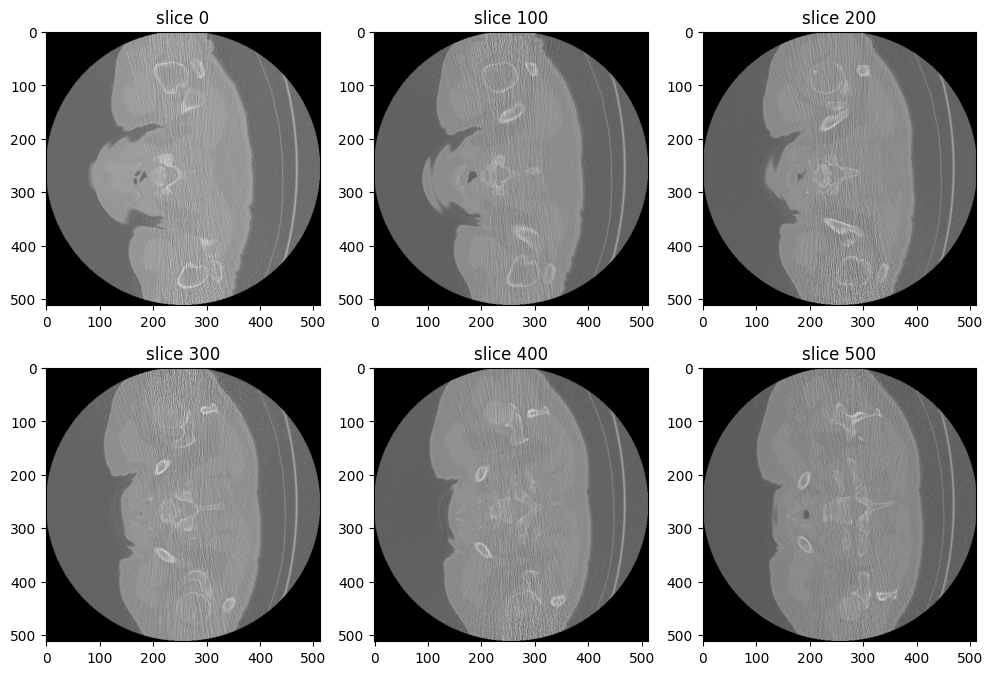

In [9]:
img = data["image"]
print(f"image shape: {img.shape}, min value: {img.min()}, max value: {img.max()}")

plt.figure("check", (12, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.title(f"slice {i * 100}")
    plt.imshow(img[:, :, i * 4], cmap="gray")
plt.show()

## Cleanup data directory

Remove directory if a temporary was used.

In [10]:
if directory is None:
    shutil.rmtree(root_dir)